In [22]:
!pip install scikit-elm --quiet
!pip install "dask[distributed]" --quiet

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, auc,
                              ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance
from sklearn.metrics import make_scorer
import torch
import torch.nn as nn
import torch.nn.functional as F

In [24]:
df = pd.read_csv('/kaggle/input/datasets/nomwesigwakeith/eyetrack/eye_tracking_data.csv', sep=';')

le = LabelEncoder()
for col in ['Gender', 'Nativelang', 'Otherlang', 'Dyslexia']:
    df[col] = le.fit_transform(df[col])

X = df.drop('Dyslexia', axis=1)
y = df['Dyslexia']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

In [25]:
class ELM:
    def __init__(self, n_neurons=1000, random_state=42):
        self.n_neurons    = n_neurons
        self.random_state = random_state

    def fit(self, X, y):
        rng = np.random.RandomState(self.random_state)
        self.W = rng.randn(X.shape[1], self.n_neurons)
        self.b = rng.randn(self.n_neurons)
        H = np.maximum(0, X @ self.W + self.b)
        self.classes_ = np.unique(y)
        T = np.zeros((len(y), len(self.classes_)))
        for i, cls in enumerate(self.classes_):
            T[:, i] = (y == cls).astype(float)
        self.beta = np.linalg.lstsq(H, T, rcond=None)[0]
        return self

    def predict_proba(self, X):
        H   = np.maximum(0, X @ self.W + self.b)
        out = H @ self.beta
        exp = np.exp(out - out.max(axis=1, keepdims=True))
        return exp / exp.sum(axis=1, keepdims=True)

    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

elm = ELM(n_neurons=1000, random_state=42)
elm.fit(X_train, y_train.values)

y_pred_elm  = elm.predict(X_test)
y_proba_elm = elm.predict_proba(X_test)[:, 1]

print("ELM Test Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_elm))
print("Precision:", precision_score(y_test, y_pred_elm))
print("Recall   :", recall_score(y_test, y_pred_elm))
print("F1 Score :", f1_score(y_test, y_pred_elm))
print("ROC-AUC  :", roc_auc_score(y_test, y_proba_elm))

ELM Test Performance
Accuracy : 0.8943758573388203
Precision: 0.5084745762711864
Recall   : 0.38461538461538464
F1 Score : 0.43795620437956206
ROC-AUC  : 0.8362873685454332


In [26]:
def build_adjacency_matrix(X, n_neighbors=5):
    knn = kneighbors_graph(
        X, n_neighbors=n_neighbors,
        mode='connectivity', include_self=True
    )
    A = torch.tensor(knn.toarray(), dtype=torch.float)
    row_sum = A.sum(dim=1, keepdim=True).clamp(min=1)
    A = A / row_sum
    return A

A_train   = build_adjacency_matrix(X_train)
A_test    = build_adjacency_matrix(X_test)
X_train_t = torch.tensor(X_train, dtype=torch.float)
X_test_t  = torch.tensor(X_test,  dtype=torch.float)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
y_test_t  = torch.tensor(y_test.values,  dtype=torch.long)

In [27]:
class GNN(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=2):
        super(GNN, self).__init__()
        self.W1 = nn.Linear(input_dim, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, A, X):
        X = A @ X
        X = self.W1(X)
        X = F.relu(X)
        X = F.dropout(X, p=0.3, training=self.training)
        X = A @ X
        X = self.W2(X)
        return F.log_softmax(X, dim=1)

In [32]:
device    = 'cpu'
gnn       = GNN(input_dim=X_train.shape[1]).to(device)
A_train   = A_train.to(device)
X_train_t = X_train_t.to(device)
y_train_t = y_train_t.to(device)

class_weights = torch.tensor([1.0, 5.0]).to(device)

lr = 0.01

gnn.train()
for epoch in range(500):
    out  = gnn(A_train, X_train_t)
    loss = F.nll_loss(out, y_train_t, weight=class_weights)
    loss.backward()
    with torch.no_grad():
        for param in gnn.parameters():
            if param.grad is not None:
                param -= lr * param.grad
                param.grad.zero_()
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/500 — Loss: {loss.item():.4f}")

Epoch 100/500 — Loss: 0.6423
Epoch 200/500 — Loss: 0.6234
Epoch 300/500 — Loss: 0.6141
Epoch 400/500 — Loss: 0.5974
Epoch 500/500 — Loss: 0.5877


In [33]:
A_test   = A_test.to(device)
X_test_t = X_test_t.to(device)

gnn.eval()
with torch.no_grad():
    out_test   = gnn(A_test, X_test_t)
    probs_gnn  = torch.exp(out_test)[:, 1].cpu().numpy()
    y_pred_gnn = out_test.argmax(dim=1).cpu().numpy()

print("GNN Test Performance")
print("Accuracy :", accuracy_score(y_test, y_pred_gnn))
print("Precision:", precision_score(y_test, y_pred_gnn))
print("Recall   :", recall_score(y_test, y_pred_gnn))
print("F1 Score :", f1_score(y_test, y_pred_gnn))
print("ROC-AUC  :", roc_auc_score(y_test, probs_gnn))

GNN Test Performance
Accuracy : 0.8422496570644719
Precision: 0.2967032967032967
Recall   : 0.34615384615384615
F1 Score : 0.31952662721893493
ROC-AUC  : 0.7275887195242035


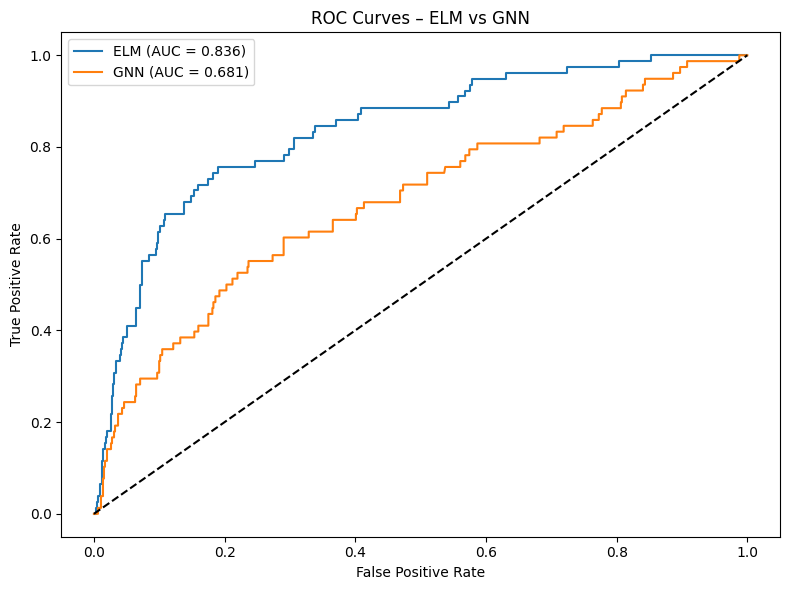

In [30]:
fpr_elm, tpr_elm, _ = roc_curve(y_test, y_proba_elm)
fpr_gnn, tpr_gnn, _ = roc_curve(y_test, probs_gnn)

plt.figure(figsize=(8, 6))
plt.plot(fpr_elm, tpr_elm, label=f'ELM (AUC = {auc(fpr_elm, tpr_elm):.3f})')
plt.plot(fpr_gnn, tpr_gnn, label=f'GNN (AUC = {auc(fpr_gnn, tpr_gnn):.3f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves – ELM vs GNN')
plt.legend()
plt.tight_layout()
plt.show()

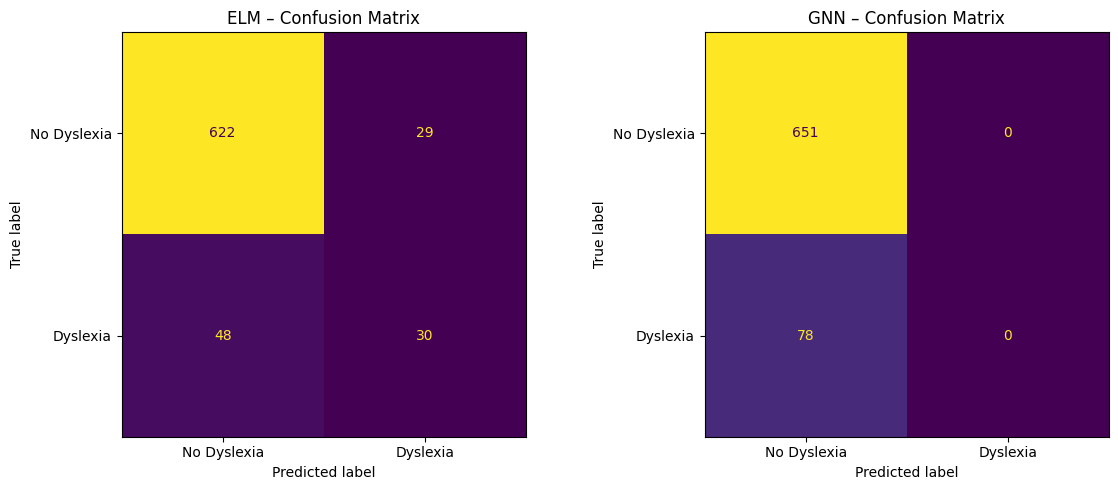

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_elm,
    display_labels=['No Dyslexia', 'Dyslexia'],
    ax=axes[0], colorbar=False
)
axes[0].set_title('ELM – Confusion Matrix')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_gnn,
    display_labels=['No Dyslexia', 'Dyslexia'],
    ax=axes[1], colorbar=False
)
axes[1].set_title('GNN – Confusion Matrix')

plt.tight_layout()
plt.show()

In [34]:
import pickle

# Save ELM
with open('/kaggle/working/elm_model.pkl', 'wb') as f:
    pickle.dump(elm, f)

print("ELM saved")

ELM saved
